# Predicting Hourly Bike Rental Demand Using Multiple Linear Regression

## 1. Project Objective

## 2. Dataset Description

## 3. Library Imports

## 4. Data Loading

## 5. Initial Data Inspection

## 6. Data Cleaning and Preprocessing

## 7. Exploratory Data Analysis

## 8. Multiple Linear Regression

## 9. Statistically Significant Variables

## 10. Model Evaluation

## 11. Regression Diagnostics

## 12. Findings and Conclusion

# Predicting Hourly Bike Rental Demand Using Multiple Linear Regression

## 1. Project Objective

The objective of this project is to develop and interpret a multiple linear
regression model for predicting hourly bike rental demand in Seoul.

The dependent variable is Rented Bike Count. The potential independent
variables include hour, weather conditions, season, holiday status, and
whether the bike-sharing system was functioning.

The analysis will identify statistically significant variables using
regression coefficients and p-values. Model performance will primarily be
evaluated using R-squared and adjusted R-squared. Test-set R-squared, mean
absolute error, and root mean squared error will also be examined to assess
the model's predictive performance on unseen observations.

In [1]:
%pip install pandas numpy matplotlib seaborn scikit-learn statsmodels openpyxl

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


## 3. Library Imports

In [2]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# File and path management
from pathlib import Path

# Display settings
# pd.set_option("display.max_columns", None)
# pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

print("Libraries imported successfully.")


Libraries imported successfully.


In [3]:
# DATA_PATH = Path("data") / "SeoulBikeData.csv"

# print("Dataset path:", DATA_PATH)
# print("File exists:", DATA_PATH.exists())

In [4]:
from pathlib import Path

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "SeoulBikeData.csv"
)

PROCESSED_DATA_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
)

FIGURE_DIR = PROJECT_ROOT / "figures"
RESULTS_DIR = PROJECT_ROOT / "results"

PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Dataset path:", RAW_DATA_PATH)
print("Dataset exists:", RAW_DATA_PATH.exists())


Project root: c:\Users\10875936\Projects\Seoul-Bike-Demand-Regression
Dataset path: c:\Users\10875936\Projects\Seoul-Bike-Demand-Regression\data\raw\SeoulBikeData.csv
Dataset exists: True


In [5]:
df = pd.read_csv(
    RAW_DATA_PATH,
    encoding="unicode_escape"
)

In [6]:
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Number of rows: 8760
Number of columns: 14


In [7]:
df.head()

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


In [8]:
df.sample(5, random_state=42)

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
6056,10/08/2018,1728,8,27.2,69,1.8,1999,21.0,0.70,0.0,0.0,Summer,No Holiday,Yes
5556,20/07/2018,822,12,32.6,51,2.1,800,21.1,3.21,0.0,0.0,Summer,No Holiday,Yes
5990,07/08/2018,658,14,34.0,50,1.2,1744,22.1,1.68,0.0,0.0,Summer,No Holiday,Yes
7674,16/10/2018,2716,18,16.9,47,1.4,1637,5.5,0.11,0.0,0.0,Autumn,No Holiday,Yes
3319,18/04/2018,1083,7,6.4,51,1.0,1398,-3.0,0.19,0.0,0.0,Spring,No Holiday,Yes


In [9]:
for position, column in enumerate(df.columns, start=1):
    print(f"{position}.{repr(column)}")

1.'Date'
2.'Rented Bike Count'
3.'Hour'
4.'Temperature(°C)'
5.'Humidity(%)'
6.'Wind speed (m/s)'
7.'Visibility (10m)'
8.'Dew point temperature(°C)'
9.'Solar Radiation (MJ/m2)'
10.'Rainfall(mm)'
11.'Snowfall (cm)'
12.'Seasons'
13.'Holiday'
14.'Functioning Day'


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Date                       8760 non-null   str    
 1   Rented Bike Count          8760 non-null   int64  
 2   Hour                       8760 non-null   int64  
 3   Temperature(°C)            8760 non-null   float64
 4   Humidity(%)                8760 non-null   int64  
 5   Wind speed (m/s)           8760 non-null   float64
 6   Visibility (10m)           8760 non-null   int64  
 7   Dew point temperature(°C)  8760 non-null   float64
 8   Solar Radiation (MJ/m2)    8760 non-null   float64
 9   Rainfall(mm)               8760 non-null   float64
 10  Snowfall (cm)              8760 non-null   float64
 11  Seasons                    8760 non-null   str    
 12  Holiday                    8760 non-null   str    
 13  Functioning Day            8760 non-null   str    
dtypes: 

In [11]:
structure_summary = pd.DataFrame({
    "column": df.columns,
    "data_type": df.dtypes.astype(str).values,
    "non_null_count": df.notna().sum().values,
    "missing_count": df.isna().sum().values,
    "unique_values": df.nunique().values
})

structure_summary

,column,data_type,non_null_count,missing_count,unique_values
0,Date,str,8760,0,365
1,Rented Bike Count,int64,8760,0,2166
2,Hour,int64,8760,0,24
3,Temperature(°C),float64,8760,0,546
4,Humidity(%),int64,8760,0,90
5,Wind speed (m/s),float64,8760,0,65
6,Visibility (10m),int64,8760,0,1789
7,Dew point temperature(°C),float64,8760,0,556
8,Solar Radiation (MJ/m2),float64,8760,0,345
9,Rainfall(mm),float64,8760,0,61


In [12]:
missing_summary = (
    df.isna()
      .sum()
      .sort_values(ascending=False)
      .to_frame(name="missing_count")
)

missing_summary["missing_percentage"] = (
    missing_summary["missing_count"] / len(df) * 100
)

missing_summary

,missing_count,missing_percentage
Date,0,0.0
Rented Bike Count,0,0.0
Hour,0,0.0
Temperature(°C),0,0.0
Humidity(%),0,0.0
Wind speed (m/s),0,0.0
Visibility (10m),0,0.0
Dew point temperature(°C),0,0.0
Solar Radiation (MJ/m2),0,0.0
Rainfall(mm),0,0.0


In [13]:
duplicate_count = df.duplicated().sum()

print(f"Number of duplicated rows: {duplicate_count:,}")

Number of duplicated rows: 0


In [14]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Rented Bike Count,8760.0,704.602055,644.997468,0.0,191.00,504.50,1065.25,3556.00
Hour,8760.0,11.500000,6.922582,0.0,5.75,11.50,17.25,23.00
Temperature(°C),8760.0,12.882922,11.944825,-17.8,3.50,13.70,22.50,39.40
Humidity(%),8760.0,58.226256,20.362413,0.0,42.00,57.00,74.00,98.00
Wind speed (m/s),8760.0,1.724909,1.036300,0.0,0.90,1.50,2.30,7.40
Visibility (10m),8760.0,1436.825799,608.298712,27.0,940.00,1698.00,2000.00,2000.00
Dew point temperature(°C),8760.0,4.073813,13.060369,-30.6,-4.70,5.10,14.80,27.20
Solar Radiation (MJ/m2),8760.0,0.569111,0.868746,0.0,0.00,0.01,0.93,3.52
Rainfall(mm),8760.0,0.148687,1.128193,0.0,0.00,0.00,0.00,35.00
Snowfall (cm),8760.0,0.075068,0.436746,0.0,0.00,0.00,0.00,8.80


In [15]:
categorical_columns = df.select_dtypes(include=["object", "category"]).columns

print("Categorical or text columns:")
print(categorical_columns.tolist())

for column in categorical_columns:
    print(f"\nColumn: {column}")
    print(df[column].value_counts(dropna=False))

Categorical or text columns:
['Date', 'Seasons', 'Holiday', 'Functioning Day']

Column: Date
Date
01/12/2017    24
02/12/2017    24
03/12/2017    24
04/12/2017    24
05/12/2017    24
              ..
26/11/2018    24
27/11/2018    24
28/11/2018    24
29/11/2018    24
30/11/2018    24
Name: count, Length: 365, dtype: int64

Column: Seasons
Seasons
Spring    2208
Summer    2208
Autumn    2184
Winter    2160
Name: count, dtype: int64

Column: Holiday
Holiday
No Holiday    8328
Holiday        432
Name: count, dtype: int64

Column: Functioning Day
Functioning Day
Yes    8465
No      295
Name: count, dtype: int64


C:\Users\10875936\AppData\Local\Temp\ipykernel_26184\967065202.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include=["object", "category"]).columns


In [16]:
print("Hour range:")
print(df["Hour"].min(), "to", df["Hour"].max())

print("\nRented Bike Count range:")
print(
    df["Rented Bike Count"].min(),
    "to",
    df["Rented Bike Count"].max()
)

Hour range:
0 to 23

Rented Bike Count range:
0 to 3556


In [17]:
zero_demand_count = (df["Rented Bike Count"] == 0).sum()
zero_demand_percentage = zero_demand_count / len(df) * 100

print(f"Zero-demand observations: {zero_demand_count:,}")
print(f"Zero-demand percentage: {zero_demand_percentage:.2f}%")

Zero-demand observations: 295
Zero-demand percentage: 3.37%


In [18]:
date_check = pd.to_datetime(
    df["Date"],
    format="%d/%m/%Y",
    errors="coerce"
)

print("Unconverted dates:", date_check.isna().sum())
print("Earliest date:", date_check.min())
print("Latest date:", date_check.max())

Unconverted dates: 0
Earliest date: 2017-12-01 00:00:00
Latest date: 2018-11-30 00:00:00


## 2. Dataset Description

The Seoul Bike Sharing Demand dataset was obtained from the UCI Machine
Learning Repository. It contains hourly bike rental counts together with
weather, temporal, seasonal, holiday, and system-operation information.

The target variable for this analysis is Rented Bike Count, which represents
the number of bicycles rented during a given hour. Candidate predictors
include hour, temperature, humidity, wind speed, visibility, dew-point
temperature, solar radiation, rainfall, snowfall, season, holiday status,
and functioning-day status.

The dataset contains 8,760 observations and 14 original columns. Initial
inspection was performed to evaluate the dataset dimensions, data types,
missing values, duplicates, category values, numerical ranges, and date
coverage before statistical modeling.

In [19]:
# Untouched copy for comparison and recovery
df_raw = df.copy(deep=True)

# Working copy that will be cleaned and transformed
df_work = df.copy(deep=True)

print("Raw copy shape:", df_raw.shape)
print("Working copy shape:", df_work.shape)

Raw copy shape: (8760, 14)
Working copy shape: (8760, 14)


In [20]:
print("CHECKPOINT-1")
print("-" * 40)
print(f"Dataset shape: {df.shape}")
print(f"Total missing values: {df.isna().sum().sum()}")
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Target minimum: {df['Rented Bike Count'].min()}")
print(f"Target maximum: {df['Rented Bike Count'].max()}")
print(f"Zero-demand rows: {(df['Rented Bike Count'] == 0).sum()}")
print(f"Hour range: {df['Hour'].min()} to {df['Hour'].max()}")
print(f"Raw copy created: {'df_raw' in globals()}")
print(f"Working copy created: {'df_work' in globals()}")

CHECKPOINT-1
----------------------------------------
Dataset shape: (8760, 14)
Total missing values: 0
Duplicate rows: 0
Target minimum: 0
Target maximum: 3556
Zero-demand rows: 295
Hour range: 0 to 23
Raw copy created: True
Working copy created: True


In [21]:
column_mapping = {
    "Date": "date",
    "Rented Bike Count": "rented_bike_count",
    "Hour": "hour",
    "Temperature(°C)": "temperature",
    "Humidity(%)": "humidity",
    "Wind speed (m/s)": "wind_speed",
    "Visibility (10m)": "visibility",
    "Dew point temperature(°C)": "dew_point_temperature",
    "Solar Radiation (MJ/m2)": "solar_radiation",
    "Rainfall(mm)": "rainfall",
    "Snowfall (cm)": "snowfall",
    "Seasons": "season",
    "Holiday": "holiday",
    "Functioning Day": "functioning_day"
}

df_work = df_work.rename(columns=column_mapping)

print(df_work.columns.tolist())

['date', 'rented_bike_count', 'hour', 'temperature', 'humidity', 'wind_speed', 'visibility', 'dew_point_temperature', 'solar_radiation', 'rainfall', 'snowfall', 'season', 'holiday', 'functioning_day']


In [22]:
df_work["date"] = pd.to_datetime(
    df_work["date"],
    format="%d/%m/%Y",
    errors="coerce"
)

print("Date data type:", df_work["date"].dtype)
print("Invalid dates:", df_work["date"].isna().sum())
print("Earliest date:", df_work["date"].min())
print("Latest date:", df_work["date"].max())

Date data type: datetime64[us]
Invalid dates: 0
Earliest date: 2017-12-01 00:00:00
Latest date: 2018-11-30 00:00:00


In [23]:
categorical_columns = [
    "season",
    "holiday",
    "functioning_day"
]

for column in categorical_columns:
    df_work[column] = df_work[column].astype(str).str.strip()


for column in categorical_columns:
    print(f"\n{column}:")
    print(df_work[column].value_counts(dropna=False))


season:
season
Spring    2208
Summer    2208
Autumn    2184
Winter    2160
Name: count, dtype: int64

holiday:
holiday
No Holiday    8328
Holiday        432
Name: count, dtype: int64

functioning_day:
functioning_day
Yes    8465
No      295
Name: count, dtype: int64


In [24]:
numerical_columns = [
    "rented_bike_count",
    "hour",
    "temperature",
    "humidity",
    "wind_speed",
    "visibility",
    "dew_point_temperature",
    "solar_radiation",
    "rainfall",
    "snowfall"
]

range_summary = df_work[numerical_columns].agg(
    ["min", "max", "mean", "median"]
).T

print(range_summary)


validation_checks = {
    "invalid_hour": (~df_work["hour"].between(0, 23)).sum(),
    "negative_bike_count": (df_work["rented_bike_count"] < 0).sum(),
    "invalid_humidity": (~df_work["humidity"].between(0, 100)).sum(),
    "negative_wind_speed": (df_work["wind_speed"] < 0).sum(),
    "negative_visibility": (df_work["visibility"] < 0).sum(),
    "negative_solar_radiation": (df_work["solar_radiation"] < 0).sum(),
    "negative_rainfall": (df_work["rainfall"] < 0).sum(),
    "negative_snowfall": (df_work["snowfall"] < 0).sum()
}

pd.Series(validation_checks, name="invalid_row_count")

                        min      max         mean   median
rented_bike_count       0.0  3556.00   704.602055   504.50
hour                    0.0    23.00    11.500000    11.50
temperature           -17.8    39.40    12.882922    13.70
humidity                0.0    98.00    58.226256    57.00
wind_speed              0.0     7.40     1.724909     1.50
visibility             27.0  2000.00  1436.825799  1698.00
dew_point_temperature -30.6    27.20     4.073813     5.10
solar_radiation         0.0     3.52     0.569111     0.01
rainfall                0.0    35.00     0.148687     0.00
snowfall                0.0     8.80     0.075068     0.00


invalid_hour                0
negative_bike_count         0
invalid_humidity            0
negative_wind_speed         0
negative_visibility         0
negative_solar_radiation    0
negative_rainfall           0
negative_snowfall           0
Name: invalid_row_count, dtype: int64

In [25]:
df_work["month"] = df_work["date"].dt.month
df_work["day_of_week"] = df_work["date"].dt.day_name()
df_work["day_of_week_number"] = df_work["date"].dt.dayofweek
df_work["is_weekend"] = (
    df_work["day_of_week_number"] >= 5
).astype(int)

df_work[
    [
        "date",
        "month",
        "day_of_week",
        "day_of_week_number",
        "is_weekend"
    ]
].head(10)

,date,month,day_of_week,day_of_week_number,is_weekend
0,2017-12-01,12,Friday,4,0
1,2017-12-01,12,Friday,4,0
2,2017-12-01,12,Friday,4,0
3,2017-12-01,12,Friday,4,0
4,2017-12-01,12,Friday,4,0
5,2017-12-01,12,Friday,4,0
6,2017-12-01,12,Friday,4,0
7,2017-12-01,12,Friday,4,0
8,2017-12-01,12,Friday,4,0
9,2017-12-01,12,Friday,4,0


In [26]:
weather_correlation = df_work[
    [
        "temperature",
        "dew_point_temperature",
        "humidity"
    ]
].corr()

weather_correlation


,temperature,dew_point_temperature,humidity
temperature,1.000000,0.912798,0.159371
dew_point_temperature,0.912798,1.000000,0.536894
humidity,0.159371,0.536894,1.000000


In [27]:
target_column = "rented_bike_count"


candidate_features = [
    "hour",
    "temperature",
    "humidity",
    "wind_speed",
    "visibility",
    "dew_point_temperature",
    "solar_radiation",
    "rainfall",
    "snowfall",
    "season",
    "holiday",
    "functioning_day",
    "day_of_week",
    "is_weekend"
]


print("Target variable:")
print(target_column)

print("\nCandidate features:")
for feature in candidate_features:
    print("-", feature)

Target variable:
rented_bike_count

Candidate features:
- hour
- temperature
- humidity
- wind_speed
- visibility
- dew_point_temperature
- solar_radiation
- rainfall
- snowfall
- season
- holiday
- functioning_day
- day_of_week
- is_weekend


In [28]:
for column in [
    "season",
    "holiday",
    "functioning_day",
    "day_of_week"
]:
    category_summary = (
        df_work[column]
        .value_counts(dropna=False)
        .to_frame(name="count")
    )

    category_summary["percentage"] = (
        category_summary["count"] / len(df_work) * 100
    )

    print(f"\n{column.upper()}")
    print(category_summary)


SEASON
        count  percentage
season                   
Spring   2208   25.205479
Summer   2208   25.205479
Autumn   2184   24.931507
Winter   2160   24.657534

HOLIDAY
            count  percentage
holiday                      
No Holiday   8328   95.068493
Holiday       432    4.931507

FUNCTIONING_DAY
                 count  percentage
functioning_day                   
Yes               8465    96.63242
No                 295     3.36758

DAY_OF_WEEK
             count  percentage
day_of_week                   
Friday        1272   14.520548
Saturday      1248   14.246575
Sunday        1248   14.246575
Monday        1248   14.246575
Tuesday       1248   14.246575
Wednesday     1248   14.246575
Thursday      1248   14.246575


In [29]:
model_columns = [target_column] + candidate_features

model_df = df_work[model_columns].copy()

print("Model dataset shape:", model_df.shape)
model_df.head()

Model dataset shape: (8760, 15)


,rented_bike_count,hour,temperature,humidity,wind_speed,visibility,dew_point_temperature,solar_radiation,rainfall,snowfall,season,holiday,functioning_day,day_of_week,is_weekend
0,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,Friday,0
1,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,Friday,0
2,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes,Friday,0
3,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,Friday,0
4,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes,Friday,0


In [30]:
numerical_features = [
    "hour",
    "temperature",
    "humidity",
    "wind_speed",
    "visibility",
    "dew_point_temperature",
    "solar_radiation",
    "rainfall",
    "snowfall",
    "is_weekend"
]

categorical_features = [
    "season",
    "holiday",
    "functioning_day",
    "day_of_week"
]

In [31]:
model_df_encoded = pd.get_dummies(
    model_df,
    columns=categorical_features,
    drop_first=True,
    dtype=int
)

print("Before encoding:", model_df.shape)
print("After encoding:", model_df_encoded.shape)

model_df_encoded.head()

Before encoding: (8760, 15)
After encoding: (8760, 22)


,rented_bike_count,hour,temperature,humidity,wind_speed,visibility,dew_point_temperature,solar_radiation,rainfall,snowfall,...,season_Summer,season_Winter,holiday_No Holiday,functioning_day_Yes,day_of_week_Monday,day_of_week_Saturday,day_of_week_Sunday,day_of_week_Thursday,day_of_week_Tuesday,day_of_week_Wednesday
0,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,...,0,1,1,1,0,0,0,0,0,0
1,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,...,0,1,1,1,0,0,0,0,0,0
2,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,...,0,1,1,1,0,0,0,0,0,0
3,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,...,0,1,1,1,0,0,0,0,0,0
4,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,...,0,1,1,1,0,0,0,0,0,0


In [32]:
from pathlib import Path

# Detect the project root
PROJECT_ROOT = Path.cwd()

# If the notebook is inside notebooks/, move to the parent folder
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

# Define output directories
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"

# Create the folder if it does not already exist
PROCESSED_DATA_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# Define output file paths
cleaned_data_path = (
    PROCESSED_DATA_DIR
    / "seoul_bike_cleaned.csv"
)

analysis_data_path = (
    PROCESSED_DATA_DIR
    / "seoul_bike_analysis.csv"
)

# Save the model-ready dataset
model_df.to_csv(
    cleaned_data_path,
    index=False
)

# Save the full analysis dataset
df_work.to_csv(
    analysis_data_path,
    index=False
)

print("Files saved successfully.")
print("Cleaned dataset:", cleaned_data_path.resolve())
print("Analysis dataset:", analysis_data_path.resolve())

Files saved successfully.
Cleaned dataset: C:\Users\10875936\Projects\Seoul-Bike-Demand-Regression\data\processed\seoul_bike_cleaned.csv
Analysis dataset: C:\Users\10875936\Projects\Seoul-Bike-Demand-Regression\data\processed\seoul_bike_analysis.csv


## 6. Data Cleaning and Preprocessing

The original column names were standardized using snake_case naming to
remove spaces, units, and special characters. The Date variable was converted
to a datetime data type using an explicit day-month-year format.

Categorical values were stripped of unnecessary spaces, and numerical
variables were checked for impossible values. The analysis also checked for
missing observations, duplicate rows, and duplicate date-hour combinations.

Calendar features were derived from the date, including day of the week and
a weekend indicator. The raw date was retained for chronological ordering
but was not used directly as a regression predictor.

The response variable is rented_bike_count. Candidate predictors include
hour, weather variables, season, holiday status, functioning-day status,
day of the week, and weekend status.

Categorical predictors will be represented using dummy variables, with one
category omitted from each group as the reference category. All observations
were retained initially, including non-functioning days. A separate
functioning-day-only model may later be used as a robustness check.

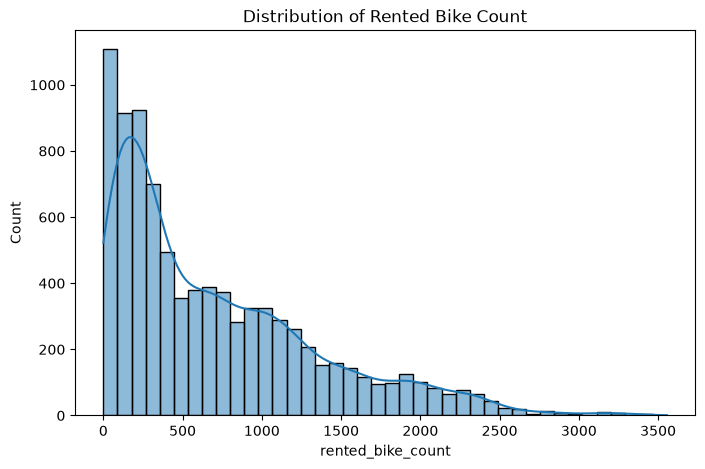

In [33]:
plt.figure(figsize=(8,5))
sns.histplot(df_work["rented_bike_count"], bins=40, kde=True)
plt.title("Distribution of Rented Bike Count")
plt.show()

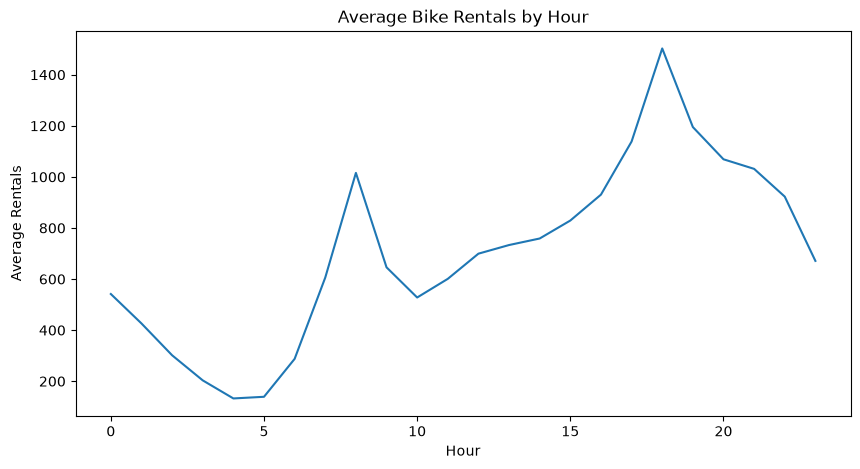

In [34]:
hourly_demand = df_work.groupby("hour")["rented_bike_count"].mean()

plt.figure(figsize=(10,5))
sns.lineplot(x=hourly_demand.index, y=hourly_demand.values)
plt.title("Average Bike Rentals by Hour")
plt.xlabel("Hour")
plt.ylabel("Average Rentals")
plt.show()

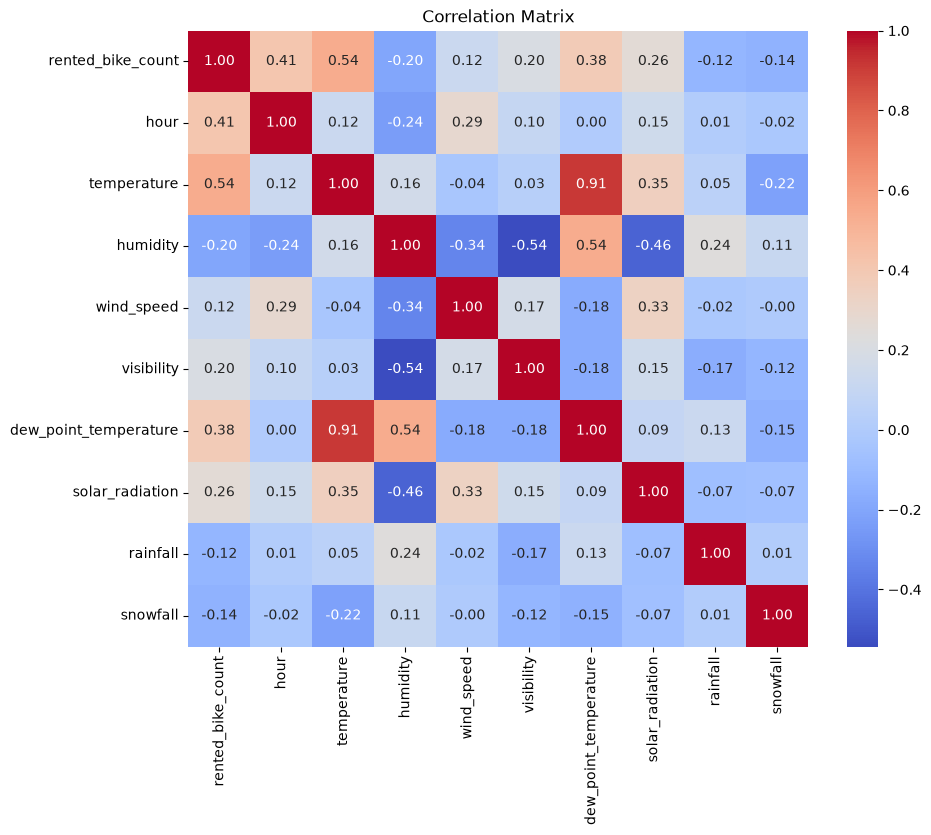

In [35]:
numeric_cols = [
    "rented_bike_count",
    "hour",
    "temperature",
    "humidity",
    "wind_speed",
    "visibility",
    "dew_point_temperature",
    "solar_radiation",
    "rainfall",
    "snowfall"
]

plt.figure(figsize=(10,8))
sns.heatmap(
    df_work[numeric_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Matrix")
plt.show()

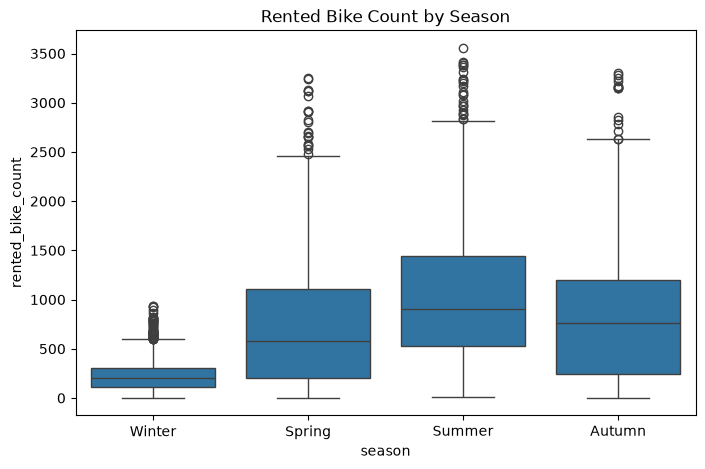

In [36]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df_work,
    x="season",
    y="rented_bike_count"
)
plt.title("Rented Bike Count by Season")
plt.show()

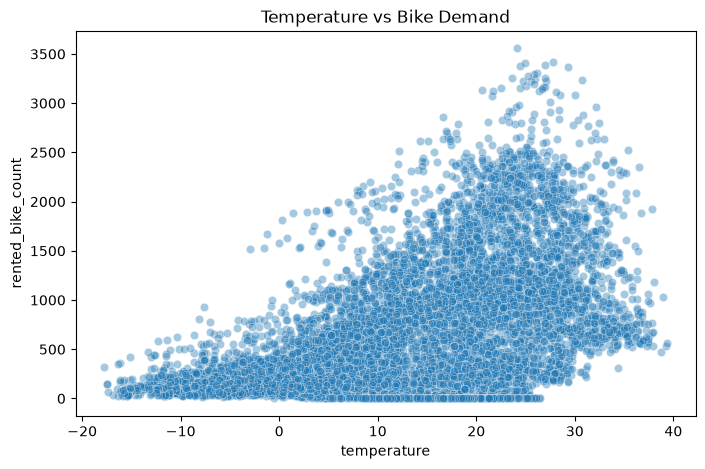

In [37]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df_work,
    x="temperature",
    y="rented_bike_count",
    alpha=0.4
)
plt.title("Temperature vs Bike Demand")
plt.show()

In [38]:
model_data = pd.get_dummies(
    model_df,
    drop_first=True
)

In [39]:
X = model_data.drop(
    "rented_bike_count",
    axis=1
)

y = model_data["rented_bike_count"]


In [40]:
split_index = int(len(model_data) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

In [41]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](21,)","[ 27.88, 19.53, -9.69,...,-46.84,-59.95,-33.96]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](21,)","['hour','temperature','humidity',...,'day_of_week_Thursday', 'day_of_week_Tuesday','day_of_week_Wednesday']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-62.19
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,21
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,20


In [42]:
y_pred_train = lr.predict(X_train)
y_pred_test = lr.predict(X_test)


In [43]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)

mae = mean_absolute_error(y_test, y_pred_test)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_test
    )
)

print("Train R2:", train_r2)
print("Test R2:", test_r2)
print("MAE:", mae)
print("RMSE:", rmse)

Train R2: 0.5535250495592985
Test R2: 0.5511198102314687
MAE: 309.6658042901203
RMSE: 410.92359944402256


In [44]:
import statsmodels.api as sm

X_sm = sm.add_constant(X)

ols_model = sm.OLS(y, X_sm).fit()

C:\Users\10875936\AppData\Local\Temp\ipykernel_26184\1096363738.py:5: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  ols_model = sm.OLS(y, X_sm).fit()


In [45]:
significant_vars = (
    ols_model.pvalues
      .sort_values()
)

significant_vars.head(20)

hour                     2.196247e-287
functioning_day_Yes      2.502483e-256
season_Winter             3.100697e-75
rainfall                  7.642656e-43
solar_radiation           2.864463e-25
humidity                  1.160311e-24
season_Spring             5.212624e-23
season_Summer             3.123358e-20
day_of_week_Sunday        1.396167e-12
is_weekend                8.622961e-12
holiday_No Holiday        5.886703e-08
temperature               1.732247e-06
wind_speed                7.037358e-04
day_of_week_Monday        1.333322e-03
snowfall                  5.085627e-03
dew_point_temperature     9.932574e-03
day_of_week_Thursday      4.957948e-02
day_of_week_Tuesday       8.145405e-02
visibility                4.811085e-01
const                     5.151889e-01
dtype: float64

In [46]:
significant = ols_model.pvalues[
    ols_model.pvalues < 0.05
]

print(significant.sort_values())

hour                     2.196247e-287
functioning_day_Yes      2.502483e-256
season_Winter             3.100697e-75
rainfall                  7.642656e-43
solar_radiation           2.864463e-25
humidity                  1.160311e-24
season_Spring             5.212624e-23
season_Summer             3.123358e-20
day_of_week_Sunday        1.396167e-12
is_weekend                8.622961e-12
holiday_No Holiday        5.886703e-08
temperature               1.732247e-06
wind_speed                7.037358e-04
day_of_week_Monday        1.333322e-03
snowfall                  5.085627e-03
dew_point_temperature     9.932574e-03
day_of_week_Thursday      4.957948e-02
dtype: float64


In [47]:
print(train_r2)
print(test_r2)

ols_model.summary()

ols_model.params.sort_values(
    key=abs,
    ascending=False
).head(15)

0.5535250495592985
0.5511198102314687


functioning_day_Yes     945.923510
season_Winter          -363.900296
season_Summer          -158.481908
season_Spring          -136.957880
holiday_No Holiday      117.059918
solar_radiation         -78.776833
day_of_week_Sunday      -70.729368
is_weekend              -67.786358
const                   -64.576220
rainfall                -58.672286
day_of_week_Monday      -55.332086
day_of_week_Thursday    -33.795467
snowfall                 31.307124
day_of_week_Tuesday     -30.092725
hour                     27.529547
dtype: float64

# Improvisation

In [48]:
# Sort by date and hour before chronological splitting
df_model_source = df_work.sort_values(
    ["date", "hour"]
).reset_index(drop=True)

# Exclude is_weekend because it is fully determined by day_of_week
corrected_features = [
    "hour",
    "temperature",
    "humidity",
    "wind_speed",
    "visibility",
    "dew_point_temperature",
    "solar_radiation",
    "rainfall",
    "snowfall",
    "season",
    "holiday",
    "functioning_day",
    "day_of_week"
]

corrected_model_df = df_model_source[
    ["rented_bike_count"] + corrected_features
].copy()

corrected_model_data = pd.get_dummies(
    corrected_model_df,
    columns=[
        "season",
        "holiday",
        "functioning_day",
        "day_of_week"
    ],
    drop_first=True,
    dtype=int
)

print("Corrected dataset shape:", corrected_model_data.shape)
print(corrected_model_data.columns.tolist())

Corrected dataset shape: (8760, 21)
['rented_bike_count', 'hour', 'temperature', 'humidity', 'wind_speed', 'visibility', 'dew_point_temperature', 'solar_radiation', 'rainfall', 'snowfall', 'season_Spring', 'season_Summer', 'season_Winter', 'holiday_No Holiday', 'functioning_day_Yes', 'day_of_week_Monday', 'day_of_week_Saturday', 'day_of_week_Sunday', 'day_of_week_Thursday', 'day_of_week_Tuesday', 'day_of_week_Wednesday']


In [49]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

X = corrected_model_data.drop(
    columns="rented_bike_count"
)

y = corrected_model_data["rented_bike_count"]

split_index = int(len(corrected_model_data) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

y_train_pred = linear_model.predict(X_train)
y_test_pred = linear_model.predict(X_test)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_rmse = np.sqrt(
    mean_squared_error(y_test, y_test_pred)
)

print(f"Training observations: {len(X_train):,}")
print(f"Testing observations: {len(X_test):,}")
print(f"Training R-squared: {train_r2:.4f}")
print(f"Testing R-squared: {test_r2:.4f}")
print(f"Test MAE: {test_mae:.2f}")
print(f"Test RMSE: {test_rmse:.2f}")

Training observations: 7,008
Testing observations: 1,752
Training R-squared: 0.5535
Testing R-squared: 0.5511
Test MAE: 309.67
Test RMSE: 410.92


In [50]:
import statsmodels.api as sm

X_train_sm = sm.add_constant(
    X_train.astype(float)
)

ols_model = sm.OLS(
    y_train.astype(float),
    X_train_sm
).fit()

print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:      rented_bike_count   R-squared:                       0.554
Model:                            OLS   Adj. R-squared:                  0.552
Method:                 Least Squares   F-statistic:                     433.1
Date:                Tue, 22 Sep 2026   Prob (F-statistic):               0.00
Time:                        17:16:36   Log-Likelihood:                -52530.
No. Observations:                7008   AIC:                         1.051e+05
Df Residuals:                    6987   BIC:                         1.052e+05
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                   -62.18

In [51]:
coefficient_table = pd.DataFrame({
    "variable": ols_model.params.index,
    "coefficient": ols_model.params.values,
    "standard_error": ols_model.bse.values,
    "t_statistic": ols_model.tvalues.values,
    "p_value": ols_model.pvalues.values,
    "ci_lower": ols_model.conf_int()[0].values,
    "ci_upper": ols_model.conf_int()[1].values
})

coefficient_table["significant_at_5_percent"] = (
    coefficient_table["p_value"] < 0.05
)

coefficient_table = coefficient_table.sort_values(
    "p_value"
).reset_index(drop=True)

coefficient_table

,variable,coefficient,standard_error,t_statistic,p_value,ci_lower,ci_upper,significant_at_5_percent
0,hour,27.876096,0.828500,33.646455,3.750662e-230,26.251984,29.500207,True
1,functioning_day_Yes,912.105530,52.748453,17.291607,1.246300e-65,808.702549,1015.508511,True
2,rainfall,-58.811523,4.650108,-12.647347,2.883488e-36,-67.927145,-49.695900,True
3,season_Winter,-400.193122,37.894647,-10.560677,7.098070e-26,-474.478133,-325.908111,True
4,solar_radiation,-83.563262,8.301668,-10.065840,1.133475e-23,-99.837051,-67.289473,True
5,humidity,-9.692537,1.100870,-8.804436,1.636963e-18,-11.850575,-7.534498,True
6,day_of_week_Sunday,-163.730801,19.483777,-8.403442,5.202487e-17,-201.924919,-125.536683,True
7,season_Summer,-146.202875,23.559400,-6.205713,5.756201e-10,-192.386450,-100.019300,True
8,season_Spring,-148.057975,27.209933,-5.441321,5.468129e-08,-201.397704,-94.718246,True
9,temperature,19.534410,3.933299,4.966419,6.981903e-07,11.823950,27.244871,True


In [52]:
coefficient_table.to_csv(
    RESULTS_DIR / "coefficient_results.csv",
    index=False
)


In [53]:
print(
    coefficient_table[
        [
            "variable",
            "coefficient",
            "p_value",
            "ci_lower",
            "ci_upper",
            "significant_at_5_percent"
        ]
    ].to_string(index=False)
)

             variable  coefficient       p_value    ci_lower    ci_upper  significant_at_5_percent
                 hour    27.876096 3.750662e-230   26.251984   29.500207                      True
  functioning_day_Yes   912.105530  1.246300e-65  808.702549 1015.508511                      True
             rainfall   -58.811523  2.883488e-36  -67.927145  -49.695900                      True
        season_Winter  -400.193122  7.098070e-26 -474.478133 -325.908111                      True
      solar_radiation   -83.563262  1.133475e-23  -99.837051  -67.289473                      True
             humidity    -9.692537  1.636963e-18  -11.850575   -7.534498                      True
   day_of_week_Sunday  -163.730801  5.202487e-17 -201.924919 -125.536683                      True
        season_Summer  -146.202875  5.756201e-10 -192.386450 -100.019300                      True
        season_Spring  -148.057975  5.468129e-08 -201.397704  -94.718246                      True
          

In [54]:
print(f"OLS R-squared: {ols_model.rsquared:.4f}")
print(f"Adjusted R-squared: {ols_model.rsquared_adj:.4f}")
print(f"F-statistic: {ols_model.fvalue:.4f}")
print(f"F-test p-value: {ols_model.f_pvalue:.6g}")
print(f"Number of observations: {int(ols_model.nobs):,}")
print(f"Durbin-Watson: {sm.stats.stattools.durbin_watson(ols_model.resid):.4f}")

OLS R-squared: 0.5535
Adjusted R-squared: 0.5522
F-statistic: 433.1127
F-test p-value: 0
Number of observations: 7,008
Durbin-Watson: 0.4923


In [55]:
from pathlib import Path

FIGURE_DIR = Path("figures")
FIGURE_DIR.mkdir(exist_ok=True)

print("Figures will be saved in:", FIGURE_DIR.resolve())

Figures will be saved in: C:\Users\10875936\Projects\Seoul-Bike-Demand-Regression\notebooks\figures


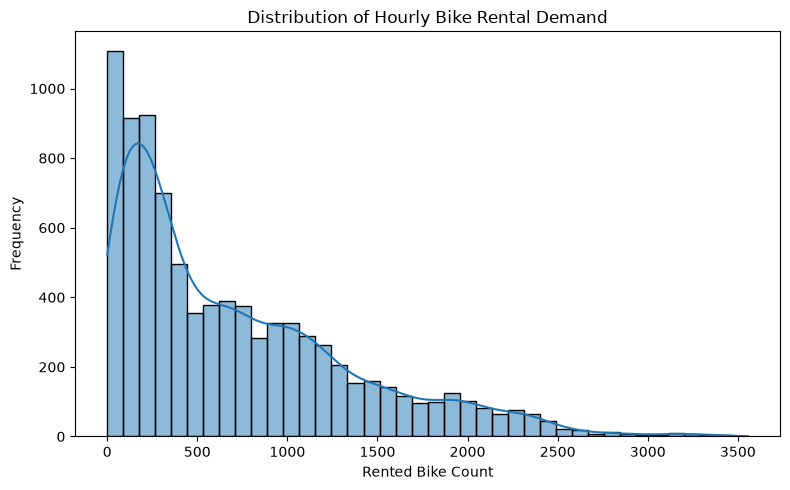

In [56]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df_work["rented_bike_count"],
    bins=40,
    kde=True
)

plt.title("Distribution of Hourly Bike Rental Demand")
plt.xlabel("Rented Bike Count")
plt.ylabel("Frequency")
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "demand_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

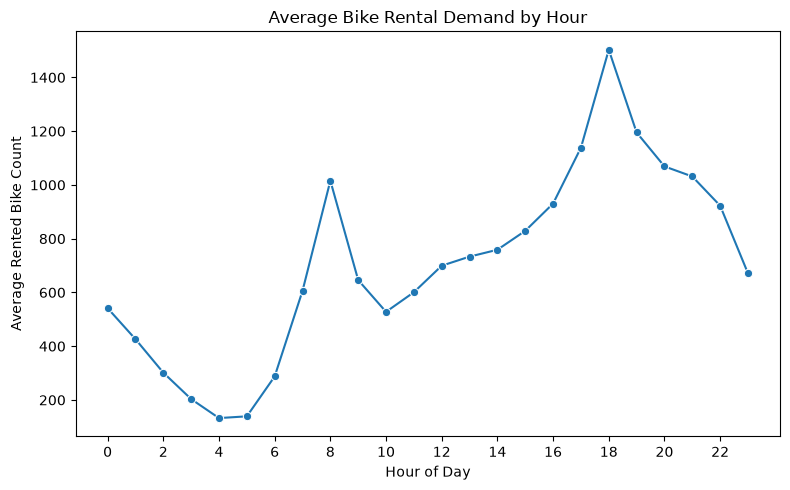

In [57]:
hourly_demand = (
    df_work.groupby("hour")["rented_bike_count"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8, 5))

sns.lineplot(
    data=hourly_demand,
    x="hour",
    y="rented_bike_count",
    marker="o"
)

plt.title("Average Bike Rental Demand by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Rented Bike Count")
plt.xticks(range(0, 24, 2))
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "hourly_demand.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

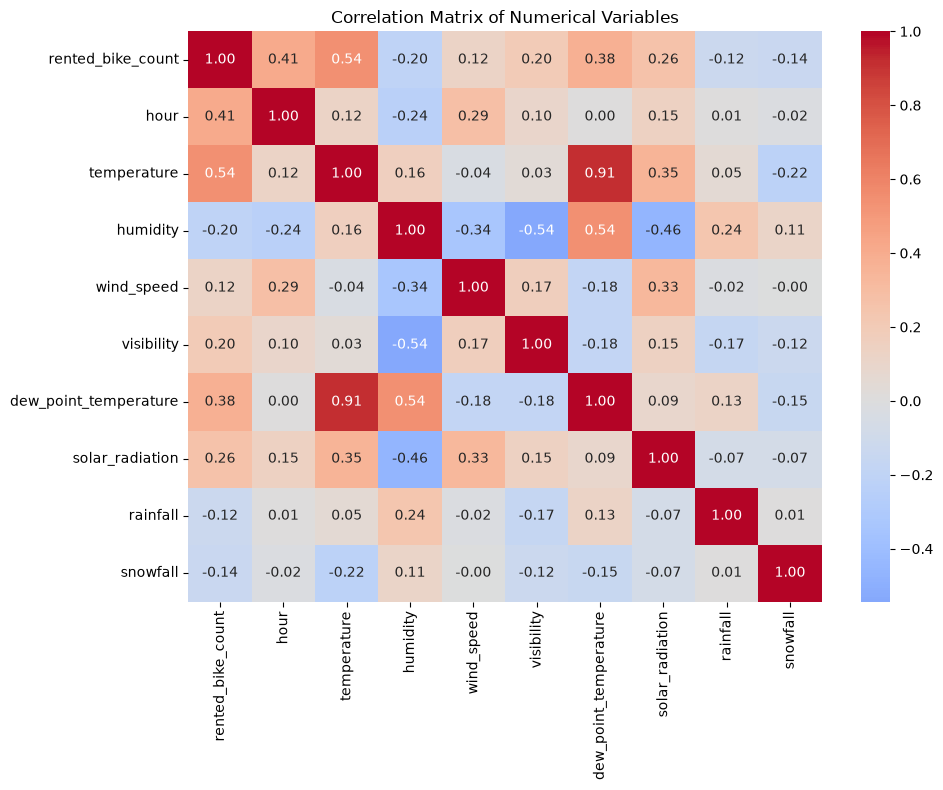

In [58]:
correlation_columns = [
    "rented_bike_count",
    "hour",
    "temperature",
    "humidity",
    "wind_speed",
    "visibility",
    "dew_point_temperature",
    "solar_radiation",
    "rainfall",
    "snowfall"
]

plt.figure(figsize=(10, 8))

sns.heatmap(
    df_work[correlation_columns].corr(),
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    center=0
)

plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

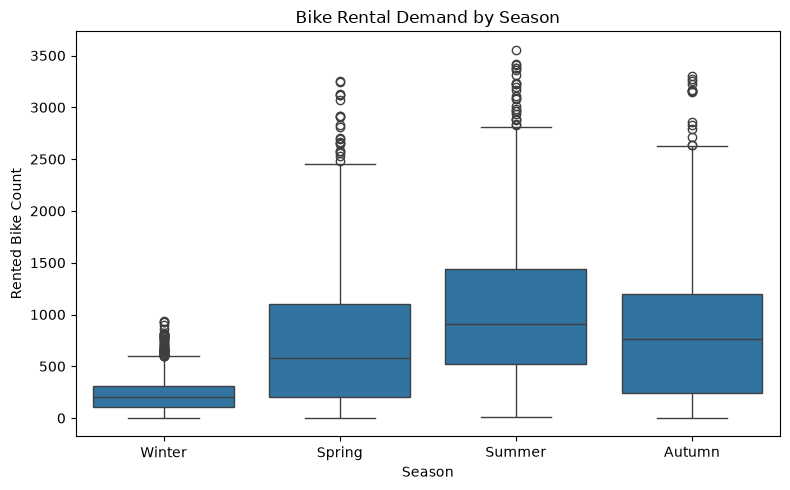

In [59]:
season_order = [
    "Winter",
    "Spring",
    "Summer",
    "Autumn"
]

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_work,
    x="season",
    y="rented_bike_count",
    order=season_order
)

plt.title("Bike Rental Demand by Season")
plt.xlabel("Season")
plt.ylabel("Rented Bike Count")
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "seasonal_demand.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

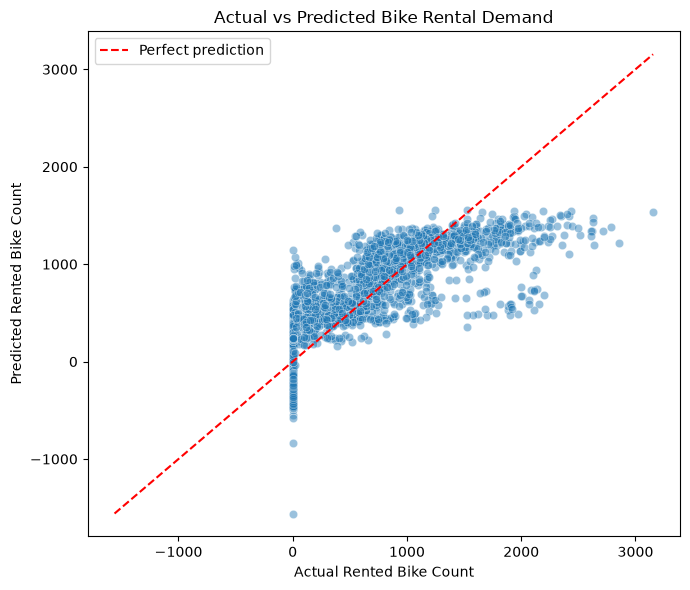

In [60]:
plt.figure(figsize=(7, 6))

sns.scatterplot(
    x=y_test,
    y=y_test_pred,
    alpha=0.45
)

minimum_value = min(y_test.min(), y_test_pred.min())
maximum_value = max(y_test.max(), y_test_pred.max())

plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    color="red",
    linestyle="--",
    label="Perfect prediction"
)

plt.title("Actual vs Predicted Bike Rental Demand")
plt.xlabel("Actual Rented Bike Count")
plt.ylabel("Predicted Rented Bike Count")
plt.legend()
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

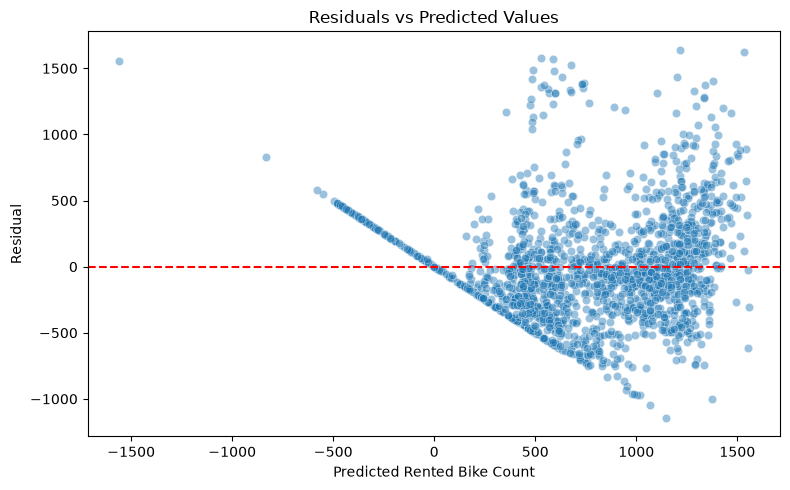

In [61]:
test_residuals = y_test - y_test_pred

plt.figure(figsize=(8, 5))

sns.scatterplot(
    x=y_test_pred,
    y=test_residuals,
    alpha=0.45
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.title("Residuals vs Predicted Values")
plt.xlabel("Predicted Rented Bike Count")
plt.ylabel("Residual")
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "residual_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [62]:
for file_path in sorted(FIGURE_DIR.glob("*.png")):
    print(file_path)

figures\actual_vs_predicted.png
figures\correlation_heatmap.png
figures\demand_distribution.png
figures\hourly_demand.png
figures\residual_plot.png
figures\seasonal_demand.png
